In [57]:
from src.post_processing import PathWrangler
import polars as pl
from pathlib import Path
from collections import defaultdict
from ergochemics.draw import draw_reaction, draw_molecule
from IPython.display import display, SVG

In [58]:
study = "/home/stef/quest_data/bottle/data/processed/short_test_branched"
known = "/home/stef/bottle/artifacts/known"
out_dir = "/home/stef/bottle/artifacts/coa_mutase_paths"

pw = PathWrangler(Path(study), Path(known))

In [6]:
tables = pw.get_paths()

In [7]:
paths = tables['paths']
krs = tables['known_reactions']
prs = tables['predicted_reactions']

pr2krs = dict(zip(prs['id'], prs['analogue_ids'].to_list()))
krs2enzymes = dict(zip(krs['id'], krs['enzymes'].to_list()))
prs2enzymes = defaultdict(list)
for p, ks in pr2krs.items():
    for k in ks:
        prs2enzymes[p] += krs2enzymes[k]

prs2smarts = dict(zip(prs['id'], prs['smarts'].to_list()))

paths = paths.select(
    pl.col("id"),
    pl.col("rxn_id"),
    (pl.col("generation") + 1).alias("step"),
    pl.col("starters").map_elements(lambda x : ";".join(x), return_dtype=pl.String),
    pl.col("targets").map_elements(lambda x : ";".join(x), return_dtype=pl.String),
    pl.col("rxn_id").replace_strict(prs2enzymes, default=[]).map_elements(lambda x : ";".join(x), return_dtype=pl.String).alias("enzymes"),
    pl.col("rxn_id").replace_strict(prs2smarts, default=None).alias("smarts")
)
paths

id,rxn_id,step,starters,targets,enzymes,smarts
str,str,i32,str,str,str,str
"""0a24a1c33085a4f1ea7f8e19ce06c3…","""5582845919356f447668dd0ea4647f…",1,"""pyruvate""","""3hpa""","""A9WGE2;A9WC35;Q8N0X4;S5N020;Q8…","""CC(=O)SCCNC(=O)CCNC(=O)C(O)C(C…"
"""0a24a1c33085a4f1ea7f8e19ce06c3…","""8c16137b4045f00069ba91d38a3b8b…",2,"""pyruvate""","""3hpa""","""A9WC41;Q9JLZ3;Q13825;Q1ZXF1;F1…","""CC(O)(CC(=O)SCCNC(=O)CCNC(=O)C…"
"""0a24a1c33085a4f1ea7f8e19ce06c3…","""9c2c777c0fea421a26efc26857522f…",3,"""pyruvate""","""3hpa""","""Q8VCH6;Q15392;Q5BQE6;Q60HC5;Q3…","""CC(=CC(=O)SCCNC(=O)CCNC(=O)C(O…"
"""0a24a1c33085a4f1ea7f8e19ce06c3…","""e86048734a2f69f1257bd92b62ddb4…",4,"""pyruvate""","""3hpa""","""Q5KUG0;A7IQE6;Q1LRY0;A7IQE5""","""CC(CC(=O)SCCNC(=O)CCNC(=O)C(O)…"
"""0a24a1c33085a4f1ea7f8e19ce06c3…","""bd616dde067e2786bec3a4ea2c6e17…",5,"""pyruvate""","""3hpa""","""Q0P5J1;Q96K12;Q7TNT2;Q0P5J1;Q9…","""NC(=O)C1=CN(C2OC(COP(=O)(O)OP(…"
"""9b13db2d9c8b6a2b40034ef19b269b…","""27450e93bf1eb2d982a541e9b34724…",1,"""glutamic_acid""","""3hpa""","""Q24SG9;Q8RHY7;P80078;Q73KI2;Q5…","""NC(CCC(=O)O)C(=O)O>>CC(C(=O)O)…"
"""9b13db2d9c8b6a2b40034ef19b269b…","""646032df080e79e8522e14d05d8548…",2,"""glutamic_acid""","""3hpa""","""A9X6P9;P76518;B0MC58;G2SYC0;O0…","""CC(C(=O)O)C(N)C(=O)O.CC(=O)SCC…"
"""9b13db2d9c8b6a2b40034ef19b269b…","""62277981d883290bf5c0d4ed258555…",3,"""glutamic_acid""","""3hpa""","""""","""NC(=O)C1=CN(C2OC(COP(=O)(O)OP(…"
"""9b13db2d9c8b6a2b40034ef19b269b…","""e86048734a2f69f1257bd92b62ddb4…",4,"""glutamic_acid""","""3hpa""","""Q5KUG0;A7IQE6;Q1LRY0;A7IQE5""","""CC(CC(=O)SCCNC(=O)CCNC(=O)C(O)…"


Direct look at parquet files

In [59]:
paths = pl.read_parquet(
    Path(study) / "paths.parquet"
)
paths.head()

path_id,rxn_id,main_pdt_id,rxn_type,generation
str,str,str,enum,i32
"""d3306109b0e69e9ea6d604bc1ef1b2…","""d11d44ec1777ea2ca09f0efbe2d1cd…","""5dda37273fbd4aeb5ccf18108bdb9e…","""predicted""",0


In [60]:
path_stats = pl.read_parquet(
    Path(study) / "path_stats.parquet"
)
path_stats.head()

id,starters,targets,dg_opt,dg_err,starter_ids,target_ids,mdf,mean_max_rxn_sim,mean_mean_rxn_sim,min_max_rxn_sim,min_mean_rxn_sim,feasibility_frac
str,list[str],list[str],list[f32],list[f32],list[str],list[str],f32,f32,f32,f32,f32,f32
"""d3306109b0e69e9ea6d604bc1ef1b2…","[""alpha_ketoglutarate"", ""NADH_CoF""]",[null],null,null,"[""6cf6db1d70f43061de31deeb417214c6fd7ad005"", ""27e471428018c3779a1b13dec34fcbc3d80f6c28""]","[""5dda37273fbd4aeb5ccf18108bdb9ee979eb882b""]",null,null,null,null,null,null


In [44]:
print(paths.shape)
print(paths.unique().shape)
print(path_stats.shape)
print(path_stats.unique().shape)

(51, 5)
(51, 5)
(26, 13)
(26, 13)


In [48]:
path_stats.filter(
    pl.col("id").str.starts_with("1298a59")
)

id,starters,targets,dg_opt,dg_err,starter_ids,target_ids,mdf,mean_max_rxn_sim,mean_mean_rxn_sim,min_max_rxn_sim,min_mean_rxn_sim,feasibility_frac
str,list[str],list[str],list[f32],list[f32],list[str],list[str],f32,f32,f32,f32,f32,f32
"""1298a5938599d2de790c2c03b74d87…",[],[null],null,null,[],"[""5dda37273fbd4aeb5ccf18108bdb9ee979eb882b""]",null,null,null,null,null,null


In [64]:
paths.filter(
    pl.col("path_id").str.starts_with("d330610")
)

path_id,rxn_id,main_pdt_id,rxn_type,generation
str,str,str,enum,i32
"""d3306109b0e69e9ea6d604bc1ef1b2…","""d11d44ec1777ea2ca09f0efbe2d1cd…","""5dda37273fbd4aeb5ccf18108bdb9e…","""predicted""",0


In [62]:
pred_rxns = pl.read_parquet(
    Path(study) / "predicted_reactions.parquet"
)

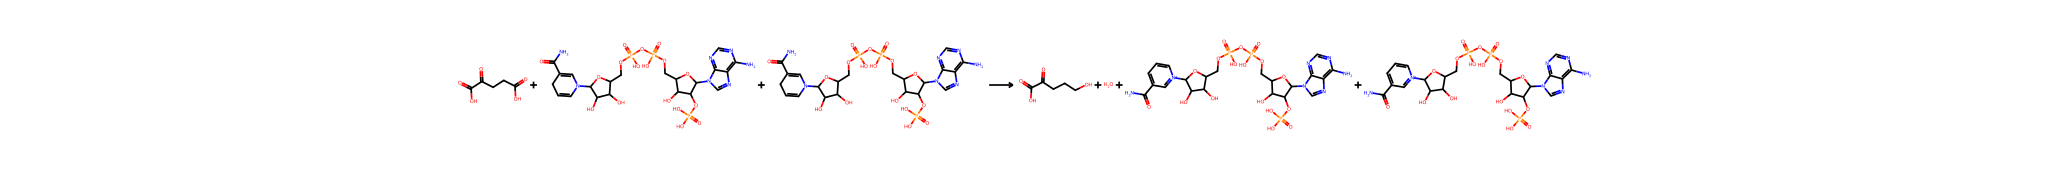

In [65]:
sma1 = pred_rxns.filter(
    pl.col("id").str.starts_with("d11d44")
)["smarts"][0]
display(SVG(draw_reaction(sma1)))

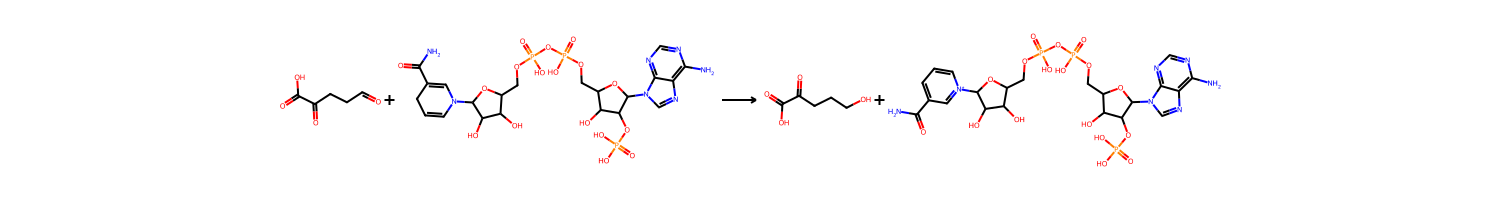

In [ ]:
sma2 = pred_rxns.filter(
    pl.col("id") == 'ad54e57aff5d4d78155a18e3aa3865239999a9bc'
)["smarts"][0]
display(SVG(draw_reaction(sma1)))

In [ ]:
display(SVG(draw_molecule()))

Formatting a pull for collaborators

In [ ]:
enzymes = tables['enzymes']


enzymes.with_columns(
    pl.col("id").map_elements(lambda x : f"https://www.uniprot.org/uniprotkb/{x}/entry", return_dtype=pl.String).alias("link"),
)

In [ ]:
paths.write_csv(
    Path(out_dir) / "250912_3hpa_paths.csv",
    separator=','
)

enzymes.write_csv(
    Path(out_dir) / "250912_3hpa_enzymes.csv",
    separator=','
)